# **PREDICTION DE LA QUALITE DE L'AIR**
Dans ce notebook, nous mettons en place un modèle pour prédire la qualité de l'air à partir de données climatiques et géographiques. Ces données sont mesurées par des capteurs localisés dans 5 endroits différents en Ouganda. Elles sont mesurées chaque heure pendant 5 jours avant bien évidemment la target qualité de l'air (variable PM25) et nous devons prédire la qualité de l'air exactement 24h après la dernière mesure.
Le temps étant une dimension importante du problème, nous allons d'abord nous assurer que nos données sont présentées sous forme de séquences de 121 mesures (24h fois 5 jours) bien dordonnées. Nous utiliserons comme algorithmes les TCN (Temporal Convolutional Networks) qui permettent de traiter efficacement les séquences. Un cleaning et un Feature engineering au préalable nous permettront de choisir le modèle adéquat que nous évaluerons à traver la RMSE.

0. Imports des données et visualisations

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import math
import gc

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving airqo_metadata.csv to airqo_metadata.csv
Saving sample_sub.csv to sample_sub.csv
Saving Test.csv to Test.csv
Saving Train.csv to Train.csv


In [ ]:
train=pd.read_csv("Train.csv")
test=pd.read_csv("Test.csv")
meta=pd.read_csv("airqo_metadata.csv")
sample_sub=pd.read_csv("sample_sub.csv")

In [ ]:
train.head()

,ID,location,temp,precip,rel_humidity,wind_dir,wind_spd,atmos_press,target
0,ID_train_0,C,"nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...",45.126304
1,ID_train_1,D,"22.53333333,21.71666667,20.83333333,20.9833333...","0.102,0.0,0.0,0.0,0.0,0.0,0.0,0.034,0.017,0.01...","0.744583333,0.808083333,0.911166667,0.91633333...","281.6643101,89.15629262,81.96853891,291.018632...","2.3775,1.126666667,0.700833333,0.3416666670000...","90.32,90.3775,90.44083333,90.4725,90.45416667,...",79.131702
2,ID_train_10,A,"28.975,27.95,29.6,26.425,22.09166667,21.775,22...","0.0,0.0,0.0,0.102,0.136,0.0,0.0,2.16,1.276,0.0...","0.573333333,0.597166667,0.5668333329999999,0.6...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","88.55166667,88.46416667,88.31916667,88.24,88.2...",32.661304
3,ID_train_100,A,"22.96666667,24.26666667,25.275,25.625,25.86666...","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.77,3.012,1.0...","0.8430833329999999,0.79025,0.7375,0.728,0.7049...","300.0850574,293.6769595,294.5174647,301.921416...","1.446666667,1.1925,1.324166667,1.5441666669999...","88.615,88.53083333,88.4,88.27166667,88.2075,88...",53.850238
4,ID_train_1000,A,"21.875,21.575,21.525,21.43333333,20.50833333,1...","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0....","0.8564166670000001,0.874916667,0.879833333,0.8...","21.83997432,17.05405341,89.26406044,123.585424...","0.1975,0.244166667,0.411666667,0.56,0.5775,0.4...","88.55666667,88.64083333,88.65833333,88.6475,88...",177.418750


In [ ]:
test.head()

,ID,location,temp,precip,rel_humidity,wind_dir,wind_spd,atmos_press
0,ID_test_0,C,"23.96666667,22.88333333,22.28333333,21.4833333...","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0....","0.6898333329999999,0.722333333,0.7755833329999...","290.1352379,328.47011289999995,323.5730796,282...","0.6333333329999999,0.725,0.955,0.8725,0.6925,0...","87.64333333,87.67,87.70583333,87.75083333,87.7..."
1,ID_test_1,C,"18.99166667,19.70833333,20.95833333,22.7833333...","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0....","0.99975,0.99725,0.956333333,0.851583333,0.7775...","295.2350543,307.6569135,313.7360236,311.518385...","0.640833333,1.244166667,1.284166667,1.2875,1.3...","87.8925,87.95666667,87.9925,87.9925,87.9808333..."
2,ID_test_10,D,"25.11666667,25.08333333,24.40833333,23.575,22....","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0....","0.760166667,0.733583333,0.78475,0.825833333,0....","77.06161145,95.48124997,61.44498258,89.4688360...","2.0133333330000003,1.3025,0.783333333,0.530833...","90.34,90.2975,90.305,90.35583333,90.4425,90.49..."
3,ID_test_100,C,"18.71666667,20.60833333,22.28333333,23.9833333...","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.604,0.0,0.0,...","0.951416667,0.92575,0.8603333329999999,0.77883...","310.7509058,316.186793,324.8167326,327.2174992...","0.745,1.169166667,1.316666667,1.385,1.40083333...","87.98833333,88.06333333,88.07833333,88.0366666..."
4,ID_test_1000,D,"17.63333333,18.05833333,19.625,21.28333333,23....","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0....","0.9,0.898333333,0.8725,0.831666667,0.820833332...","334.6054069,329.6848561000001,322.7668036,312....","0.620833333,0.5,0.456666667,0.558333333,1.0158...","90.515,90.5575,90.62333333,90.6825,90.67916667..."


In [ ]:
meta.head()

,Unnamed: 0,location,loc_altitude,km2,aspect,dist_motorway,dist_trunk,dist_primary,dist_secondary,dist_tertiary,dist_unclassified,dist_residential,popn,hh,hh_cook_charcoal,hh_cook_firewood,hh_burn_waste
0,0,A,1122.4,1.9,194.0,NaN,NaN,14.695789,343.595039,575.917422,330.609776,254.307415,4763,809,508,43,142
1,1,B,1155.4,5.4,219.8,NaN,528.078476,2172.680462,1144.376412,531.103271,65.142004,1.042809,22243,5735,116,1144,239
2,2,C,1178.3,8.5,168.7,NaN,32.885520,4794.704552,12.730489,72.459340,406.967815,13.931350,97895,26873,21316,751,9835
3,3,D,980.8,0.8,90.0,NaN,NaN,265.896472,NaN,339.693908,76.024389,11.601442,3596,663,7,651,99
4,4,E,1186.5,1.6,121.0,NaN,850.423131,NaN,1738.872942,137.722087,449.591885,3.836589,6064,1297,985,26,43


Les bases train et test contiennent les mesures dans données climatiques. En effet un test équivaut à recolter les mesures sur un capteur chaque heure pendant 5 jours. On peut avoir plusiseurs tests pour un seul capteur et chaque ligne de ces bases fournissent l'ID du test, le capteur (location) et pour chaque feature climatiques les mesures et la target associée (mesurée 24h après).

La base meta contient les données géographiques identifiables à chaque capteur. Donc on peut merge cette base avec train sur location pour l'entrainement.

La suite, il faut qu'on s'assure d'avoir le bon nombre de mesures pour chaque feature climatique et chaque test c'est à dire 121 et enuite construire un format de données qui n'aligne pas les mesures dans une seule cellule mais produit une séquence pour permettre au modèle de compter chaque mesure de chaque feature à chaque heure comme une information à part entière mais dont l'ordre dans la séquence détermine la valeur de la target.

1. Data cleaning

In [ ]:
len(train.loc[4, 'precip'])

487

In [ ]:
print(f"Le nombre d'éléments dans la première ligne de la colonne 'précip' est: {len(train.loc[0, 'precip'])}")

Le nombre d'éléments dans la première ligne de la colonne 'précip' est: 483


In [ ]:
#Avoir le nombre d'éléments séparés par virgule pour chaque
train.loc[0, 'precip']

number_elements = train.loc[0, 'precip'].split(',')
len(number_elements)


121

In [ ]:
train.loc[59, 'temp']
number_elements = train.loc[59, 'temp'].split(',')
len(number_elements)


121

In [ ]:
#Fonction de vérification du nombre d'éléments
SEQ_COLS = ["temp", "precip", "rel_humidity", "wind_dir", "wind_spd", "atmos_press"]
ID_COL = "ID"
LOC_COL = "location"
TARGET_COL = "target"
T_EXPECTED = 121

def seq_len(s: str) -> int:
    # Nombre de valeurs séparées par virgule
    return len(str(s).split(","))

# Longueur des séquences par colonne
lens = pd.DataFrame({c: train[c].map(seq_len) for c in SEQ_COLS})

print("Résumé des longueurs par colonne :")
print(lens.describe())

# Combien de lignes ne respectent pas 121 ?
bad_mask = (lens != T_EXPECTED).any(axis=1)
print(f"\nLignes avec au moins une colonne # {T_EXPECTED}: {bad_mask.sum()} / {len(train)}")

# Voir quelques exemples problématiques
if bad_mask.any():
    sample_bad = train.loc[bad_mask, [ID_COL] + SEQ_COLS].head(5)
    sample_bad_lens = lens.loc[bad_mask].head(5)
    print("\nExemples (ID) avec longueurs anormales :")
    print(pd.concat([sample_bad[[ID_COL]], sample_bad_lens], axis=1))

Résumé des longueurs par colonne :
          temp   precip  rel_humidity  wind_dir  wind_spd  atmos_press
count  15539.0  15539.0       15539.0   15539.0   15539.0      15539.0
mean     121.0    121.0         121.0     121.0     121.0        121.0
std        0.0      0.0           0.0       0.0       0.0          0.0
min      121.0    121.0         121.0     121.0     121.0        121.0
25%      121.0    121.0         121.0     121.0     121.0        121.0
50%      121.0    121.0         121.0     121.0     121.0        121.0
75%      121.0    121.0         121.0     121.0     121.0        121.0
max      121.0    121.0         121.0     121.0     121.0        121.0

Lignes avec au moins une colonne # 121: 0 / 15539


In [ ]:
#Fonction de séparation des mesures
def parse_seq_str(s: str, T: int) -> np.ndarray:
    """
    Convertit "1.0,2.0,nan,..." en array float (T,)
    - nan/"" -> np.nan
    - pad/truncate si besoin
    """
    toks = str(s).split(",")
    arr = np.array(
        [np.nan if t.strip().lower() == "nan" or t.strip() == "" else float(t) for t in toks],
        dtype=np.float32
    )
    if len(arr) < T:
        arr = np.concatenate([arr, np.full((T - len(arr),), np.nan, dtype=np.float32)])
    elif len(arr) > T:
        arr = arr[:T]
    return arr

In [ ]:
#Fonction de construction de la séquence
def build_X_raw(df: pd.DataFrame, seq_cols, T: int) -> np.ndarray:
    """
    Retourne X_raw: (N: nombre de tests ID, T: 121 mesures ,F_raw: vecteur feature)
    """
    N = len(df)
    F = len(seq_cols)
    X = np.zeros((N, T, F), dtype=np.float32)
    for j, col in enumerate(seq_cols):
        X[:, :, j] = np.stack([parse_seq_str(v, T) for v in df[col].values], axis=0)
    return X


X_raw_train = build_X_raw(train, SEQ_COLS, T_EXPECTED)
X_raw_test  = build_X_raw(test,  SEQ_COLS, T_EXPECTED)

y = train[TARGET_COL].values.astype(np.float32)
print("X_raw_train:", X_raw_train.shape, "y:", y.shape)
print("X_raw_test :", X_raw_test.shape)


X_raw_train: (15539, 121, 6) y: (15539,)
X_raw_test : (5035, 121, 6)


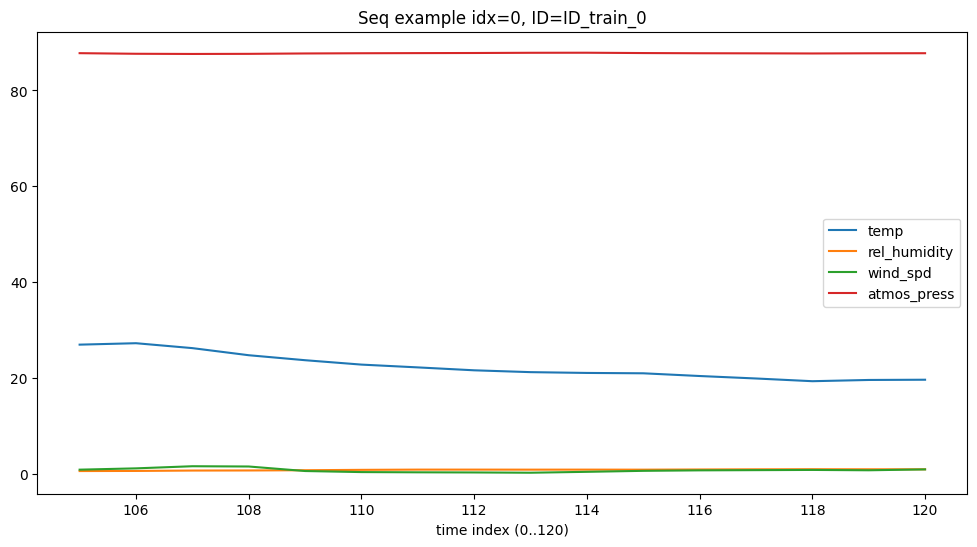

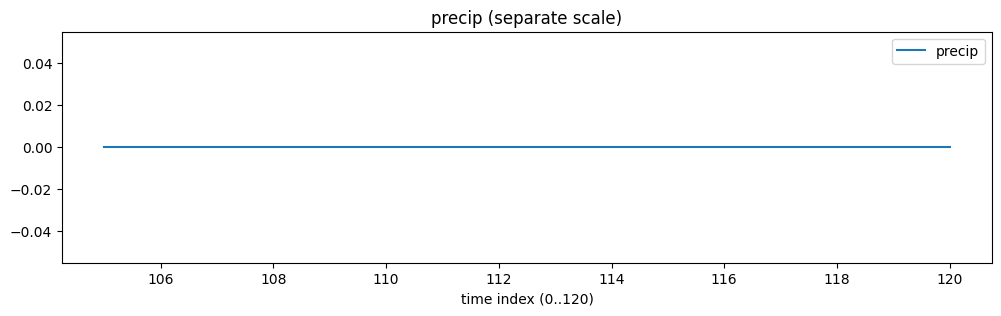

In [ ]:
#Plot d’un exemple de séquence pour vérifier l’alignement
import matplotlib.pyplot as plt
def plot_one_sequence(X_raw, seq_cols, df, idx=0):
    t = np.arange(X_raw.shape[1])
    plt.figure(figsize=(12,6))
    for name in ["temp", "rel_humidity", "wind_spd", "atmos_press"]:
        j = seq_cols.index(name)
        plt.plot(t, X_raw[idx,:,j], label=name)
    plt.title(f"Seq example idx={idx}, ID={df.loc[idx, ID_COL]}")
    plt.xlabel("time index (0..120)")
    plt.legend()
    plt.show()

    # precip à part (souvent échelle différente)
    plt.figure(figsize=(12,3))
    j = seq_cols.index("precip")
    plt.plot(t, X_raw[idx,:,j], label="precip")
    plt.title("precip (separate scale)")
    plt.xlabel("time index (0..120)")
    plt.legend()
    plt.show()

plot_one_sequence(X_raw_train, SEQ_COLS, train, idx=0)

A partir d'ici, nous allons nettoyer les features. D'abord la direction du vent wind_dir est donnée en dégré qui est une variable circulaire. Nous choisissons la transformation sin/cos et de plus il y'a des nan dans les données que nous allons traiter.

In [ ]:
# wind_dir -> sin/cos
def winddir_to_sincos(X_raw: np.ndarray, seq_cols):
    """
    Remplace wind_dir par wind_sin & wind_cos.
    X_raw: (N,T,F_raw)
    Retourne X_new: (N,T,F_raw+1) et new_cols
    """
    cols = list(seq_cols)
    widx = cols.index("wind_dir")

    wind = X_raw[:,:,widx]                # (N,T)
    theta = np.deg2rad(wind)              # NaN propagé
    wind_sin = np.sin(theta).astype(np.float32)
    wind_cos = np.cos(theta).astype(np.float32)

    X_wo = np.delete(X_raw, widx, axis=2) # enlève wind_dir
    X_new = np.concatenate([X_wo, wind_sin[...,None], wind_cos[...,None]], axis=2)

    new_cols = [c for c in cols if c!="wind_dir"] + ["wind_sin","wind_cos"]
    return X_new, new_cols

X_w_train, SEQ_COLS_W = winddir_to_sincos(X_raw_train, SEQ_COLS)
X_w_test,  _          = winddir_to_sincos(X_raw_test,  SEQ_COLS)

print("Après wind sin/cos:", X_w_train.shape, SEQ_COLS_W)

Après wind sin/cos: (15539, 121, 7) ['temp', 'precip', 'rel_humidity', 'wind_spd', 'atmos_press', 'wind_sin', 'wind_cos']


In [ ]:
# y
y = train[TARGET_COL].values.astype(np.float32)
print("y :", y.shape)

y : (15539,)


Pour la gestion des NaN, nous allons d'abord noter où se trouvent exactement les Nan, créer un masque qui pour chaque feature donne un binaire (1, il y'avait Nan,  pas de NaN). Ce masque est informatif pour notre modèle à venir. On imputera avec la médiane des valeurs voisines.

In [ ]:
#Masque
mask_nan = np.isnan(X_w_train)
nan_per_feature = mask_nan.sum(axis=(0,1))
nan_rate_feature = nan_per_feature / (mask_nan.shape[0]*mask_nan.shape[1])

print("Taux de NaN par feature:")
for name, rate in zip(SEQ_COLS_W, nan_rate_feature):
    print(f"  {name:12s}: {rate:.4f}")

Taux de NaN par feature:
  temp        : 0.0634
  precip      : 0.0632
  rel_humidity: 0.0628
  wind_spd    : 0.1037
  atmos_press : 0.0610
  wind_sin    : 0.1037
  wind_cos    : 0.1037


In [ ]:
#Fonctions d'imputation
def interp_1d(arr):
    s = pd.Series(arr)
    s = s.interpolate(limit_direction="both")
    return s.values.astype(np.float32)

def impute_interp_with_mask(X: np.ndarray):
    """
    X: (N,T,F) avec NaN
    Retourne:
      - X_imp: (N,T,F) imputé
      - mask : (N,T,F) 1 si NaN original, sinon 0
    """
    mask = np.isnan(X).astype(np.float32)
    X_imp = X.copy()
    N, T, F = X.shape

    # Interpolation feature-wise par séquence
    for i in range(N):
        for f in range(F):
            x = X_imp[i,:,f]
            if np.isnan(x).any():
                X_imp[i,:,f] = interp_1d(x)

    # Fallback médiane globale si des NaN persistent
    flat = X.reshape(-1, F)
    med = np.nanmedian(flat, axis=0).astype(np.float32)
    med = np.where(np.isnan(med), 0.0, med)

    for f in range(F):
        X_imp[:,:,f] = np.where(np.isnan(X_imp[:,:,f]), med[f], X_imp[:,:,f])

    return X_imp.astype(np.float32), mask.astype(np.float32)

In [ ]:
#Imputation sur X_raw et ajout du masque aux vecteur feature
X_imp_train, mask_train = impute_interp_with_mask(X_w_train)
X_imp_test,  mask_test  = impute_interp_with_mask(X_w_test)

# X_final = concat([X_imp, mask])
X_final_train = np.concatenate([X_imp_train, mask_train], axis=2).astype(np.float32)
X_final_test  = np.concatenate([X_imp_test,  mask_test],  axis=2).astype(np.float32)

print("X_final_train:", X_final_train.shape)
print("X_final_test :", X_final_test.shape)

X_final_train: (15539, 121, 14)
X_final_test : (5035, 121, 14)


2. Features engineering

Pour améliorer nos features, nous allons merge les metadata avec notre table de base et créer de nouvelles variables.

Le merging de metadata se fait sur location. Il y'a des NaN dans les données, notamment pour la variable Distance ( qui donne la distance au goudron le plus proche), lorsque la valeur est supérieure à 5000 c'est NaN. On va donc imputer par 5000 , standardiser et donc garder un masque.

In [ ]:
from sklearn.preprocessing import StandardScaler

def build_X_meta(train_df, test_df, meta_path="airqo_metadata.csv", loc_col="location"):
    meta_df = pd.read_csv(meta_path)

    # Merge (on garde uniquement location du train/test pour alignement)
    train_m = train_df[[loc_col]].merge(meta_df, on=loc_col, how="left")
    test_m  = test_df[[loc_col]].merge(meta_df,  on=loc_col, how="left")

    # Colonnes distance Dist_*
    dist_cols = [c for c in meta_df.columns if c.startswith("Dist_")]

    # Colonnes numériques
    meta_cols = [c for c in meta_df.columns if c != loc_col]
    num_cols  = [c for c in meta_cols if pd.api.types.is_numeric_dtype(train_m[c])]

    # 1) Flags "far or missing" pour Dist_*
    for c in dist_cols:
        train_m[f"is_far_or_missing_{c}"] = train_m[c].isna().astype(np.float32)
        test_m[f"is_far_or_missing_{c}"]  = test_m[c].isna().astype(np.float32)
        # Impute dist -> 5000 (borne sémantique)
        train_m[c] = train_m[c].fillna(5000.0)
        test_m[c]  = test_m[c].fillna(5000.0)

    # 2) Flags "missing" pour autres colonnes numériques
    other_cols = [c for c in num_cols if c not in dist_cols]
    for c in other_cols:
        train_m[f"is_missing_{c}"] = train_m[c].isna().astype(np.float32)
        test_m[f"is_missing_{c}"]  = test_m[c].isna().astype(np.float32)

        med = train_m[c].median()
        if pd.isna(med):
            med = 0.0
        train_m[c] = train_m[c].fillna(med)
        test_m[c]  = test_m[c].fillna(med)


    # Colonnes indicatrices
    flag_cols = [c for c in train_m.columns if c.startswith("is_far_or_missing_") or c.startswith("is_missing_")]

    # Standardisation sur les valeurs numériques (pas sur flags)
    scaler = StandardScaler()
    X_val_train = scaler.fit_transform(train_m[num_cols]).astype(np.float32)
    X_val_test  = scaler.transform(test_m[num_cols]).astype(np.float32)

    X_flag_train = train_m[flag_cols].values.astype(np.float32)
    X_flag_test  = test_m[flag_cols].values.astype(np.float32)

    # Concat final
    X_meta_train = np.concatenate([X_val_train, X_flag_train], axis=1).astype(np.float32)
    X_meta_test  = np.concatenate([X_val_test,  X_flag_test],  axis=1).astype(np.float32)

    return X_meta_train, X_meta_test, num_cols, flag_cols, scaler

X_meta_train, X_meta_test, meta_num_cols, meta_flag_cols, meta_scaler = build_X_meta(train, test, "airqo_metadata.csv", LOC_COL)
print("X_meta_train:", X_meta_train.shape, "X_meta_test:", X_meta_test.shape)

X_meta_train: (15539, 32) X_meta_test: (5035, 32)


Ici on va calculer les statistiques pour enrichir nos features mais en utilisant les X_train et X_test de base où on a pas fait d'imputation. C'est pour garder les stats fiables.

In [ ]:
def slope_1d(x):
    t = np.arange(len(x), dtype=np.float32)
    # polyfit simple
    return np.polyfit(t, x, 1)[0].astype(np.float32)

def build_X_stat_from_Ximp_mask(X_imp: np.ndarray, mask: np.ndarray):
    """
    X_imp: (N,T,F0) imputé
    mask : (N,T,F0) 1 si manquant original
    Retourne X_stat: (N, D_stat)
    """
    N, T, F0 = X_imp.shape
    feats = []

    for i in range(N):
        row = []
        for f in range(F0):
            x = X_imp[i,:,f]
            last24 = x[-24:] if T >= 24 else x

            # stats sur X_imp
            row.extend([
                x.mean(), x.std(), x.min(), x.max(),
                np.quantile(x, 0.1), np.quantile(x, 0.5), np.quantile(x, 0.9),
                last24.mean(), last24.std(),
                slope_1d(x),
                np.mean(np.abs(np.diff(x)))  # variabilité
            ])

            # info missing depuis mask
            row.append(mask[i,:,f].mean())

        feats.append(np.array(row, dtype=np.float32))

    return np.stack(feats, axis=0)

X_stat_train = build_X_stat_from_Ximp_mask(X_imp_train, mask_train)
X_stat_test  = build_X_stat_from_Ximp_mask(X_imp_test,  mask_test)

print("X_stat_train:", X_stat_train.shape, "X_stat_test:", X_stat_test.shape)

X_stat_train: (15539, 84) X_stat_test: (5035, 84)


Ici on va merge les X_stat_train et X_stat_test qui contiennent les features de bases avec masque et les X_meta_train et X_meta_test contenant les features de metadata et leur masque pour créer une deuxième base de données informatives en plus de celles X_train_final et X_test_final

In [ ]:
X_stat_train = np.nan_to_num(X_stat_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_stat_test  = np.nan_to_num(X_stat_test,  nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

In [ ]:
X_tab_train = np.concatenate([X_meta_train, X_stat_train], axis=1).astype(np.float32)
X_tab_test  = np.concatenate([X_meta_test,  X_stat_test],  axis=1).astype(np.float32)

print("X_tab_train:", X_tab_train.shape)
print("X_tab_test :", X_tab_test.shape)

# vérification de l'alignement
assert X_final_train.shape[0] == X_tab_train.shape[0] == y.shape[0]
assert X_final_test.shape[0]  == X_tab_test.shape[0]

X_tab_train: (15539, 116)
X_tab_test : (5035, 116)


In [ ]:
X_tab_train = np.nan_to_num(X_tab_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_tab_test  = np.nan_to_num(X_tab_test,  nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

3. Modeling et évaluation

Pour le modèle on va utiliser une double branche TCN composée de : Branche TCN qui va encoder X_final_train de shape (N, 121, 14)
(valeurs imputées + mask, concat en canaux) et Branche MLP : X_tab_train de shape (N, D_tab)
où D_tab = dimension(X_meta) + dimension(X_stat)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class AirQoDataset(Dataset):
    def __init__(self, X_seq, X_tab, y=None):
        self.X_seq = X_seq
        self.X_tab = X_tab
        self.y = y

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        # Conv1D attend (C,T) -> on transpose (T,C) vers (C,T)
        x_seq = torch.tensor(self.X_seq[idx].transpose(1,0), dtype=torch.float32)
        x_tab = torch.tensor(self.X_tab[idx], dtype=torch.float32)

        if self.y is None:
            return x_seq, x_tab

        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return x_seq, x_tab, y

In [ ]:
import torch.nn as nn

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, dilation=1, dropout=0.1):
        super().__init__()
        pad = (k - 1) * dilation

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=k, dilation=dilation, padding=pad)
        self.act1  = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=k, dilation=dilation, padding=pad)
        self.act2  = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.down = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        # x: (B,C,T)
        y = self.conv1(x)
        y = y[:, :, :x.size(-1)]   # crop pour garder longueur T
        y = self.drop1(self.act1(y))

        y = self.conv2(y)
        y = y[:, :, :x.size(-1)]
        y = self.drop2(self.act2(y))

        return y + self.down(x)

In [ ]:
class TwoBranchTCN(nn.Module):
    def __init__(self, seq_channels, tab_dim):
        super().__init__()

        # Branche séquence
        self.tcn = nn.Sequential(
            TCNBlock(seq_channels, 64,  k=3, dilation=1),
            TCNBlock(64,          64,  k=3, dilation=2),
            TCNBlock(64,          128, k=3, dilation=4),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)  # -> (B,128,1)

        # Branche tabulaire (metadata + stats)
        self.mlp_tab = nn.Sequential(
            nn.Linear(tab_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Tête finale
        self.head = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

    def forward(self, x_seq, x_tab):
        h_seq = self.tcn(x_seq)              # (B,128,T)
        h_seq = self.pool(h_seq).squeeze(-1) # (B,128)

        h_tab = self.mlp_tab(x_tab)          # (B,64)

        h = torch.cat([h_seq, h_tab], dim=1)
        out = self.head(h).squeeze(1)
        return out

Entraînement Cross Validation (StratifiedKFold par location) + early stopping

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.sqrt(mean_squared_error(y_true, y_pred))

def train_one_epoch(model, loader, optim, device):
    model.train()
    crit = nn.MSELoss()
    losses = []
    for x_seq, x_tab, yb in loader:
        x_seq, x_tab, yb = x_seq.to(device), x_tab.to(device), yb.to(device)
        optim.zero_grad()
        pred = model(x_seq, x_tab)
        loss = crit(pred, yb)
        loss.backward()
        optim.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    preds = []
    for batch in loader:
        if len(batch)==3:
            x_seq, x_tab, _ = batch
        else:
            x_seq, x_tab = batch
        x_seq, x_tab = x_seq.to(device), x_tab.to(device)
        p = model(x_seq, x_tab).cpu().numpy()
        preds.append(p)
    return np.concatenate(preds)

device = "cuda" if torch.cuda.is_available() else "cpu"

loc = train[LOC_COL].astype(str).values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(train), dtype=np.float32)

for fold, (tr_idx, va_idx) in enumerate(skf.split(train, loc), 1):
    ds_tr = AirQoDataset(X_final_train[tr_idx], X_tab_train[tr_idx], y[tr_idx])
    ds_va = AirQoDataset(X_final_train[va_idx], X_tab_train[va_idx], y[va_idx])

    dl_tr = DataLoader(ds_tr, batch_size=128, shuffle=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=256, shuffle=False, num_workers=0)

    model = TwoBranchTCN(seq_channels=X_final_train.shape[2], tab_dim=X_tab_train.shape[1]).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3)

    best = 1e9
    patience = 5
    bad = 0
    best_state = None

    for epoch in range(30):
        tr_loss = train_one_epoch(model, dl_tr, optim, device)
        va_pred = predict_loader(model, dl_va, device)
        va_rmse = rmse(y[va_idx], va_pred)

        print(f"[Fold {fold}] epoch {epoch+1:02d} loss={tr_loss:.4f} val_rmse={va_rmse:.4f}")

        if va_rmse < best:
            best = va_rmse
            bad = 0
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    va_pred = predict_loader(model, dl_va, device)
    oof[va_idx] = va_pred

    print(f"[Fold {fold}] best_rmse={best:.4f}")

print("OOF RMSE:", rmse(y, oof))

[Fold 1] epoch 01 loss=1995.0576 val_rmse=40.8109
[Fold 1] epoch 02 loss=1756.2664 val_rmse=38.0271
[Fold 1] epoch 03 loss=1608.8398 val_rmse=39.0868
[Fold 1] epoch 04 loss=1580.5171 val_rmse=37.7485
[Fold 1] epoch 05 loss=1538.8159 val_rmse=37.4232
[Fold 1] epoch 06 loss=1546.4767 val_rmse=37.5583
[Fold 1] epoch 07 loss=1528.9560 val_rmse=37.0680
[Fold 1] epoch 08 loss=1533.1588 val_rmse=37.6872
[Fold 1] epoch 09 loss=1500.3667 val_rmse=38.6473
[Fold 1] epoch 10 loss=1466.9815 val_rmse=36.6527
[Fold 1] epoch 11 loss=1448.2106 val_rmse=36.6395
[Fold 1] epoch 12 loss=1427.6102 val_rmse=36.0595
[Fold 1] epoch 13 loss=1432.6674 val_rmse=36.3020
[Fold 1] epoch 14 loss=1414.8102 val_rmse=35.8615
[Fold 1] epoch 15 loss=1411.8584 val_rmse=35.4748
[Fold 1] epoch 16 loss=1362.8007 val_rmse=36.8372
[Fold 1] epoch 17 loss=1353.1011 val_rmse=34.9932
[Fold 1] epoch 18 loss=1324.0716 val_rmse=35.3502
[Fold 1] epoch 19 loss=1311.1131 val_rmse=34.7391
[Fold 1] epoch 20 loss=1306.2368 val_rmse=35.0591


Entraîner final + prédiction sur test + soumission

In [ ]:
# Train final sur tout le train
ds_full = AirQoDataset(X_final_train, X_tab_train, y)
dl_full = DataLoader(ds_full, batch_size=128, shuffle=True, num_workers=0)

model = TwoBranchTCN(seq_channels=X_final_train.shape[2], tab_dim=X_tab_train.shape[1]).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(30):
    tr_loss = train_one_epoch(model, dl_full, optim, device)
    print(f"[Final] epoch {epoch+1:02d} loss={tr_loss:.4f}")

# Predict test
ds_test = AirQoDataset(X_final_test, X_tab_test, y=None)
dl_test = DataLoader(ds_test, batch_size=256, shuffle=False, num_workers=0)

test_pred = predict_loader(model, dl_test, device)

sub = pd.DataFrame({ID_COL: test[ID_COL].values, TARGET_COL: test_pred})
sub.to_csv("submission.csv", index=False)
sub.head()

[Final] epoch 01 loss=1939.2443
[Final] epoch 02 loss=1638.7950
[Final] epoch 03 loss=1546.5695
[Final] epoch 04 loss=1535.0653
[Final] epoch 05 loss=1519.4228
[Final] epoch 06 loss=1477.2781
[Final] epoch 07 loss=1464.3745
[Final] epoch 08 loss=1416.1122
[Final] epoch 09 loss=1413.5937
[Final] epoch 10 loss=1379.3967
[Final] epoch 11 loss=1380.5221
[Final] epoch 12 loss=1364.1960
[Final] epoch 13 loss=1307.6126
[Final] epoch 14 loss=1296.3561
[Final] epoch 15 loss=1290.8815
[Final] epoch 16 loss=1272.4830
[Final] epoch 17 loss=1240.8549
[Final] epoch 18 loss=1244.1641
[Final] epoch 19 loss=1218.5913
[Final] epoch 20 loss=1223.4140
[Final] epoch 21 loss=1190.0556
[Final] epoch 22 loss=1196.4559
[Final] epoch 23 loss=1184.5046
[Final] epoch 24 loss=1181.1137
[Final] epoch 25 loss=1164.4912
[Final] epoch 26 loss=1165.2061
[Final] epoch 27 loss=1155.7107
[Final] epoch 28 loss=1147.8722
[Final] epoch 29 loss=1123.9101
[Final] epoch 30 loss=1105.0785


,ID,target
0,ID_test_0,77.363297
1,ID_test_1,72.772934
2,ID_test_10,48.613266
3,ID_test_100,74.016563
4,ID_test_1000,59.161835


4. Visualisations des prédictions et explicabilité du modèle

Distributions (y vs OOF) + distribution test

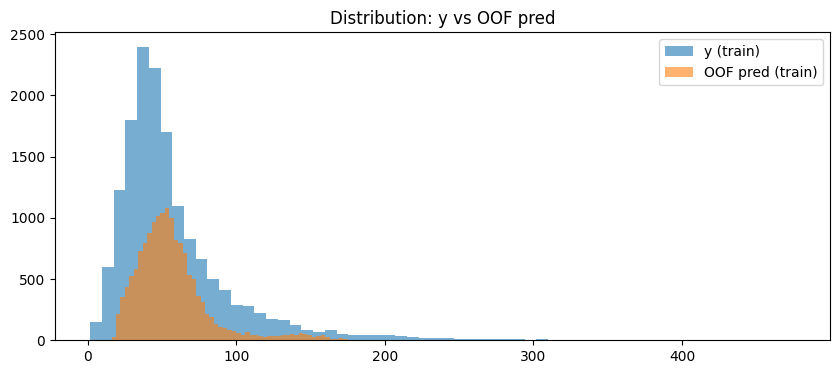

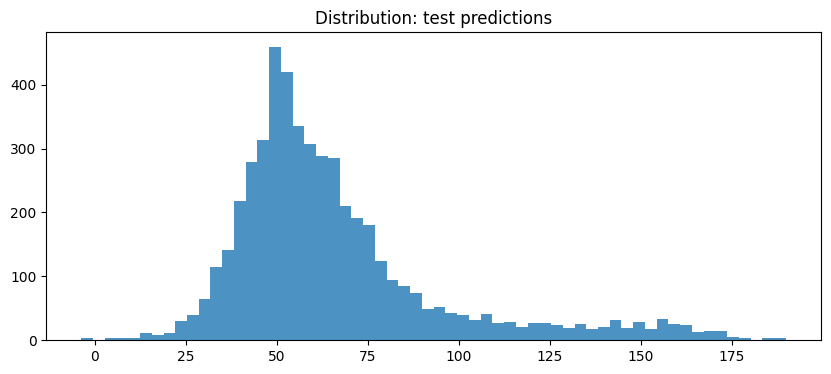

Test pred summary:
count    5035.000000
mean       66.003822
std        29.922911
min        -3.747381
1%         22.496892
5%         33.848097
10%        39.291652
50%        58.123024
90%       106.851968
95%       139.496094
99%       166.306667
max       189.780853
dtype: float64


In [ ]:
plt.figure(figsize=(10,4))
plt.hist(y, bins=60, alpha=0.6, label="y (train)")
plt.hist(oof, bins=60, alpha=0.6, label="OOF pred (train)")
plt.title("Distribution: y vs OOF pred")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.hist(test_pred, bins=60, alpha=0.8)
plt.title("Distribution: test predictions")
plt.show()

print("Test pred summary:")
print(pd.Series(test_pred).describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))

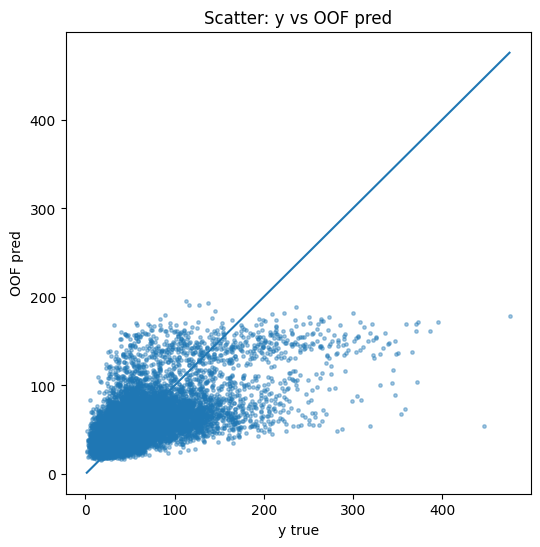

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y, oof, s=6, alpha=0.4)
mn = float(min(np.min(y), np.min(oof)))
mx = float(max(np.max(y), np.max(oof)))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("y true")
plt.ylabel("OOF pred")
plt.title("Scatter: y vs OOF pred")
plt.show()

Analyse des erreurs par location (RMSE + MAE + stats)

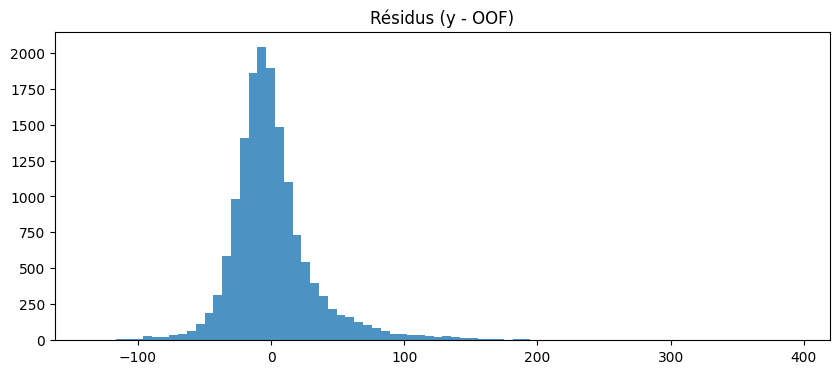

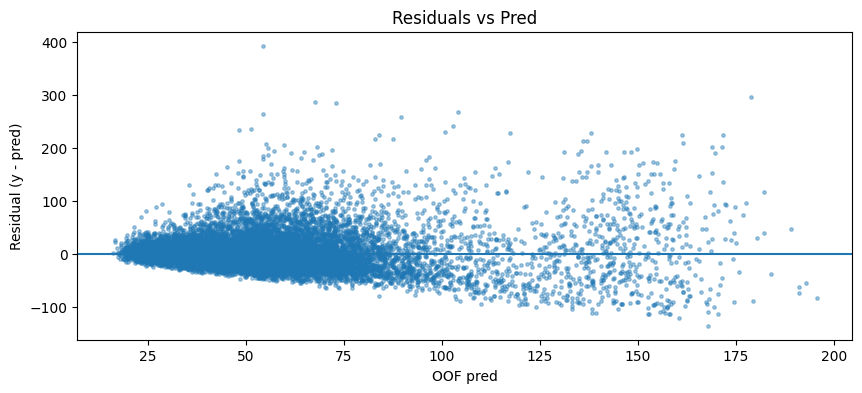

Residual summary:
count    15539.000000
mean         1.514010
std         33.812885
min       -135.835815
1%         -68.441416
5%         -38.239619
10%        -29.295724
50%         -3.557545
90%         37.420611
95%         61.998826
99%        129.708694
max        393.018250
dtype: float64


In [ ]:
resid = y - oof

plt.figure(figsize=(10,4))
plt.hist(resid, bins=80, alpha=0.8)
plt.title("Résidus (y - OOF)")
plt.show()

plt.figure(figsize=(10,4))
plt.scatter(oof, resid, s=6, alpha=0.4)
plt.axhline(0.0)
plt.xlabel("OOF pred")
plt.ylabel("Residual (y - pred)")
plt.title("Residuals vs Pred")
plt.show()

print("Residual summary:")
print(pd.Series(resid).describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))

In [ ]:
df_diag = train[[ID_COL, LOC_COL]].copy()
df_diag["y"] = y
df_diag["oof"] = oof
df_diag["resid"] = resid
df_diag["abs_err"] = np.abs(resid)

df_top = df_diag.sort_values("abs_err", ascending=False).head(20)
df_top

,ID,location,y,oof,resid,abs_err
2083,ID_train_11872,A,447.339996,54.321747,393.018250,393.018250
5660,ID_train_15091,C,475.820007,178.830658,296.989349,296.989349
6627,ID_train_1978,C,354.460205,67.644547,286.815674,286.815674
15251,ID_train_974,A,358.401093,72.939407,285.461670,285.461670
13594,ID_train_8248,A,371.926819,104.135269,267.791565,267.791565
8360,ID_train_3537,A,318.994781,54.341953,264.652832,264.652832
7638,ID_train_2888,A,347.811737,89.569092,258.242645,258.242645
3816,ID_train_13431,A,343.592285,102.902473,240.689819,240.689819
8220,ID_train_3410,D,287.689423,51.231907,236.457520,236.457520
14553,ID_train_9110,A,282.613159,48.257229,234.355927,234.355927


In [ ]:
rows = []
for loc in sorted(train[LOC_COL].astype(str).unique()):
    part = df_diag[df_diag[LOC_COL].astype(str) == loc]
    loc_rmse = rmse(part["y"].values, part["oof"].values)
    loc_mae  = float(np.mean(np.abs(part["resid"].values)))
    rows.append([loc, len(part), loc_rmse, loc_mae, float(part["resid"].mean()), float(part["resid"].std())])

df_loc = pd.DataFrame(rows, columns=["location","n","rmse","mae","resid_mean","resid_std"]).sort_values("rmse", ascending=False)
df_loc


,location,n,rmse,mae,resid_mean,resid_std
2,C,1753,56.436583,41.558517,-0.444646,56.450935
0,A,5122,35.576511,23.067274,1.792364,35.534821
3,D,4990,28.442148,20.105885,1.957762,28.377529
1,B,767,27.096916,20.266186,1.363889,27.080229
4,E,2907,19.752634,13.761807,1.482572,19.700308


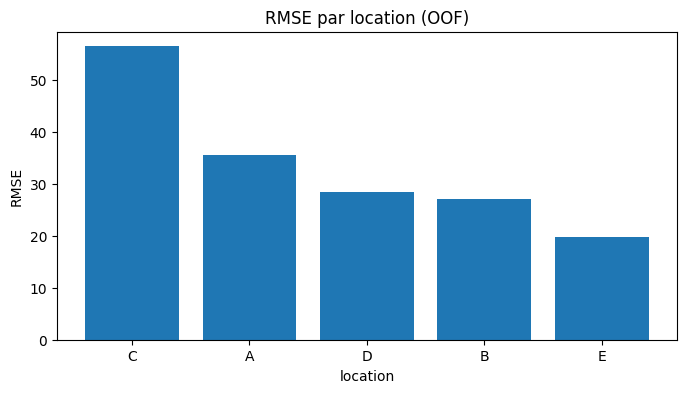

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(df_loc["location"].astype(str), df_loc["rmse"])
plt.title("RMSE par location (OOF)")
plt.xlabel("location")
plt.ylabel("RMSE")
plt.show()

Explicabilité via LightGBM sur X_tab (interpretable)

On fait une CV rapide stratifiée par location (comme ton NN), et on récupère le score OOF LightGBM (sur X_tab) et l'importance moyenne sur folds.

In [ ]:
# --- 1) META feature names ---
# si tu as encore meta_num_cols/meta_flag_cols en mémoire, utilise-les directement.
# sinon, saute à la section 1.3.

meta_feature_names = list(meta_num_cols) + list(meta_flag_cols)

# --- 2) STAT feature names ---
stat_parts = [
    "mean","std","min","max","q10","q50","q90",
    "mean_last24","std_last24","slope","mad_diff","missing_rate"
]

seq_names = list(SEQ_COLS_W)  # ex: ["temp","precip","rel_humidity","wind_spd","atmos_press","wind_sin","wind_cos"]

stat_feature_names = [f"{s}__{p}" for s in seq_names for p in stat_parts]

# --- 3) TAB feature names ---
tab_feature_names = meta_feature_names + stat_feature_names

print("tab_feature_names:", len(tab_feature_names))
print("X_tab_train dim:", X_tab_train.shape[1])

assert len(tab_feature_names) == X_tab_train.shape[1], "Mismatch: feature names length != X_tab_train columns"

tab_feature_names: 116
X_tab_train dim: 116


In [ ]:
import lightgbm as lgb
# Sécuriser les NaN/Inf dans X_tab (au cas où)
X_tab_train_clean = np.nan_to_num(X_tab_train, nan=0.0, posinf=0.0, neginf=0.0)

loc = train[LOC_COL].astype(str).values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(train), dtype=np.float32)
imp_accum = np.zeros(X_tab_train_clean.shape[1], dtype=np.float64)

params = dict(
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_tab_train_clean, loc), 1):
    Xtr, Xva = X_tab_train_clean[tr_idx], X_tab_train_clean[va_idx]
    ytr, yva = y[tr_idx], y[va_idx]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(200, verbose=False)]
    )

    pred = model.predict(Xva)
    oof_lgb[va_idx] = pred.astype(np.float32)

    imp_accum += model.feature_importances_.astype(np.float64)
    print(f"[LGB fold {fold}] RMSE:", rmse(yva, pred))

print("LightGBM OOF RMSE:", rmse(y, oof_lgb))

imp_mean = imp_accum / skf.get_n_splits()
imp_df = pd.DataFrame({"feature": tab_feature_names, "importance_gain": imp_mean})
imp_df = imp_df.sort_values("importance_gain", ascending=False)
imp_df.head(30)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031667 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19326
[LightGBM] [Info] Number of data points in the train set: 12431, number of used features: 100
[LightGBM] [Info] Start training from score 58.345031


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LGB fold 1] RMSE: 24.553695354276762
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19323
[LightGBM] [Info] Number of data points in the train set: 12431, number of used features: 100
[LightGBM] [Info] Start training from score 58.231470


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LGB fold 2] RMSE: 25.487918379230607
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19326
[LightGBM] [Info] Number of data points in the train set: 12431, number of used features: 100
[LightGBM] [Info] Start training from score 58.153419


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LGB fold 4] RMSE: 25.210207385081628
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19307
[LightGBM] [Info] Number of data points in the train set: 12432, number of used features: 100
[LightGBM] [Info] Start training from score 58.106668


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LGB fold 5] RMSE: 26.810666907226473
LightGBM OOF RMSE: 25.701937662545504


,feature,importance_gain
41,temp__slope,11602.8
89,atmos_press__slope,10779.2
77,wind_spd__slope,10416.6
113,wind_cos__slope,10084.8
101,wind_sin__slope,9726.8
65,rel_humidity__slope,9437.6
88,atmos_press__std_last24,8682.0
100,wind_sin__std_last24,8064.8
99,wind_sin__mean_last24,8042.2
112,wind_cos__std_last24,7252.0


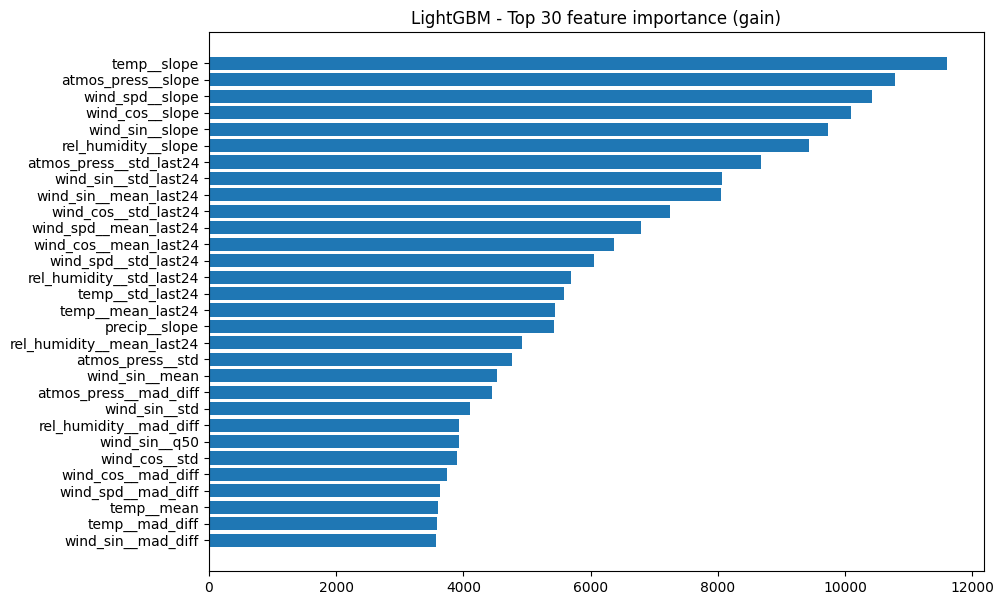

In [ ]:
topk = 30
top = imp_df.head(topk).iloc[::-1]

plt.figure(figsize=(10,7))
plt.barh(top["feature"], top["importance_gain"])
plt.title("LightGBM - Top 30 feature importance (gain)")
plt.show()

On calcule la permutation importance sur un fold validation (ou sur un subset) pour éviter que ça dure des heures.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19326
[LightGBM] [Info] Number of data points in the train set: 12431, number of used features: 100
[LightGBM] [Info] Start training from score 58.345031


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


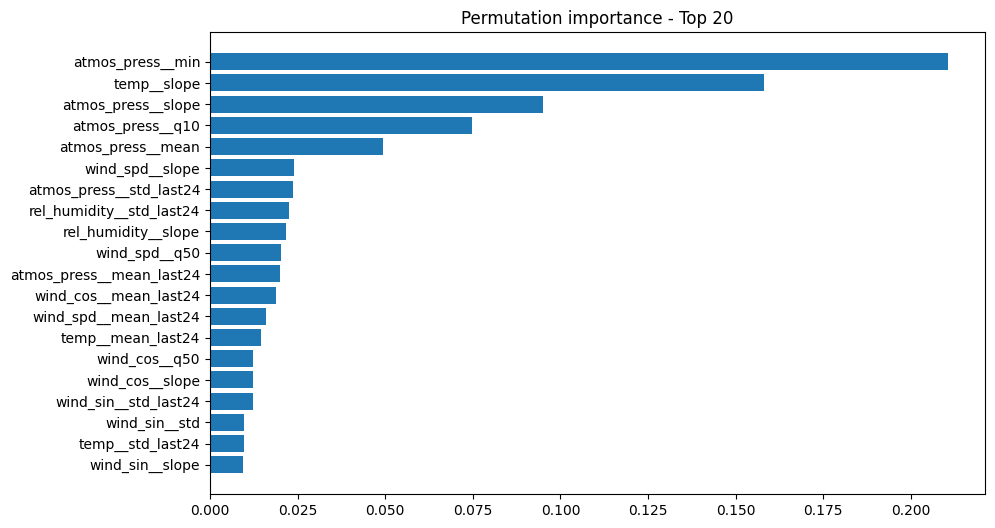

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

# Prendre un fold (1er fold) pour permutation importance
tr_idx, va_idx = next(skf.split(X_tab_train_clean, loc))
Xtr, Xva = X_tab_train_clean[tr_idx], X_tab_train_clean[va_idx]
ytr, yva = y[tr_idx], y[va_idx]

model_pi = lgb.LGBMRegressor(**params)
model_pi.fit(
    Xtr, ytr,
    eval_set=[(Xva, yva)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(200, verbose=False)]
)

# Permutation importance (peut prendre un moment)
perm = permutation_importance(
    model_pi, Xva, yva,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": tab_feature_names,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False)

perm_df.head(30)


topk = 20
top = perm_df.head(topk).iloc[::-1]

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["perm_mean"])
plt.title("Permutation importance - Top 20")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from google.colab import files  # si tu es sur Colab

ID_COL = "ID"
LOC_COL = "location"

# 1) Nettoyage tabulaire (éviter NaN/Inf dans le CSV)
X_tab_train_clean = np.nan_to_num(X_tab_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_tab_test_clean  = np.nan_to_num(X_tab_test,  nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# 2) Construire des DataFrames tabulaires avec noms de colonnes
Xtab_train_df = pd.DataFrame(X_tab_train_clean, columns=tab_feature_names)
Xtab_test_df  = pd.DataFrame(X_tab_test_clean,  columns=tab_feature_names)

# 3) Bundle TRAIN (OOF)
df_train_bundle = train[[ID_COL, LOC_COL]].copy()
df_train_bundle["y"] = y.astype(np.float32)
df_train_bundle["oof"] = oof.astype(np.float32)
df_train_bundle["test_pred"] = np.nan  # pour homogénéiser
df_train_bundle = pd.concat([df_train_bundle, Xtab_train_df], axis=1)
df_train_bundle.insert(0, "section", "train_rows")

# 4) Bundle TEST (pred)
df_test_bundle = test[[ID_COL, LOC_COL]].copy()
df_test_bundle["y"] = np.nan
df_test_bundle["oof"] = np.nan
df_test_bundle["test_pred"] = test_pred.astype(np.float32)
df_test_bundle = pd.concat([df_test_bundle, Xtab_test_df], axis=1)
df_test_bundle.insert(0, "section", "test_rows")

# 5) Bundle importances (gain)
df_imp_gain = imp_df.copy()
df_imp_gain.insert(0, "section", "importance_gain")

# 6) Bundle importances (permutation)
df_imp_perm = perm_df.copy()
df_imp_perm.insert(0, "section", "importance_permutation")

# 7) Harmoniser les colonnes (car gain/perm n'ont pas les mêmes colonnes que train/test)
#    On "aligne" tout en union de colonnes, les colonnes absentes seront NaN.
all_cols = list(pd.Index(df_train_bundle.columns)
                .union(df_test_bundle.columns)
                .union(df_imp_gain.columns)
                .union(df_imp_perm.columns))

df_train_bundle = df_train_bundle.reindex(columns=all_cols)
df_test_bundle  = df_test_bundle.reindex(columns=all_cols)
df_imp_gain     = df_imp_gain.reindex(columns=all_cols)
df_imp_perm     = df_imp_perm.reindex(columns=all_cols)

# 8) Concatenation finale (un seul CSV)
bundle = pd.concat([df_train_bundle, df_test_bundle, df_imp_gain, df_imp_perm], axis=0, ignore_index=True)

# 9) Sauvegarde
out_csv = "airqo_streamlit_bundle.csv"
bundle.to_csv(out_csv, index=False)

print("CSV unique créé:", out_csv)
print("Sections disponibles:", bundle["section"].value_counts().to_dict())
print("Taille (rows, cols):", bundle.shape)

/tmp/ipython-input-2481448708.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bundle = pd.concat([df_train_bundle, df_test_bundle, df_imp_gain, df_imp_perm], axis=0, ignore_index=True)


CSV unique créé: airqo_streamlit_bundle.csv
Sections disponibles: {'train_rows': 15539, 'test_rows': 5035, 'importance_gain': 116, 'importance_permutation': 116}
Taille (rows, cols): (20806, 126)


In [ ]:
import os, zipfile
from google.colab import files

# liste des fichiers que tu veux mettre sur GitHub / utiliser
artifact_files = [
    "airqo_streamlit_bundle.csv",  # si tu utilises le bundle unique
    "app.py",
    "requirements.txt",
    # si tu veux aussi garder les versions séparées (optionnel)
    "oof.npy", "y.npy", "test_pred.npy",
    "X_tab_train.npy", "X_tab_test.npy",
    "train_keys.csv", "test_keys.csv",
    "tab_feature_names.csv",
    "diag_train_oof.csv", "diag_by_location.csv",
    "lgb_importance_gain.csv", "lgb_importance_permutation.csv"
]

# ne garder que ceux qui existent réellement
artifact_files = [f for f in artifact_files if os.path.exists(f)]
print("Fichiers trouvés:", artifact_files)

zip_name = "airqo_artifacts_for_github.zip"
with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for f in artifact_files:
        zf.write(f)

print("ZIP créé:", zip_name, "size:", os.path.getsize(zip_name), "bytes")
files.download(zip_name)

Fichiers trouvés: ['airqo_streamlit_bundle.csv']
ZIP créé: airqo_artifacts_for_github.zip size: 7290783 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>